In [1]:
# %%
# https://www.sc-best-practices.org/conditions/gsea_pathway.html#id380
# Kang HM, Subramaniam M, Targ S, et al. Multiplexed droplet single-cell RNA-sequencing using natural genetic variation
#   Nat Biotechnol. 2020 Nov;38(11):1356]. Nat Biotechnol. 2018;36(1):89-94. doi:10.1038/nbt.4042

# %%


from pathlib import Path

import dotenv
import numpy as np
import pandas as pd
import scanpy as sc
from isrobust.bio import (
    build_hipathia_renamers,
    get_adj_matrices,
    get_reactome_adj,
    sync_gexp_adj,
)
from isrobust.datasets import load_kang
from isrobust.utils import set_all_seeds
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import minmax_scale


from pathlib import Path

import dotenv
import numpy as np
import pandas as pd
import scanpy as sc
from ivae_scorer.bio import (
    build_hipathia_renamers,
    get_adj_matrices,
    get_reactome_adj,
    sync_gexp_adj,
)
from ivae_scorer.datasets import load_kang
from ivae_scorer.utils import set_all_seeds
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import minmax_scale
from tensorflow.keras import callbacks
from ivae_scorer.models import build_kegg_vae

model_kind = "binn-reactome"
debug = 1
seed = 42
model_kind = str(model_kind)
debug = bool(int(debug))
seed = int(seed)


project_path = Path(dotenv.find_dotenv()).parent
results_path = project_path.joinpath("results")
results_path.mkdir(exist_ok=True, parents=True)
data_path = project_path.joinpath("data")
data_path.mkdir(exist_ok=True, parents=True)
mygene_path = data_path.joinpath("mygene")
mygene_path.mkdir(exist_ok=True, parents=True)
figs_path = results_path.joinpath("figs")
figs_path.mkdir(exist_ok=True, parents=True)
tables_path = results_path.joinpath("tables")
tables_path.mkdir(exist_ok=True, parents=True)

set_all_seeds(seed=seed)

sc.set_figure_params(dpi=300, color_map="inferno")
sc.settings.verbosity = 1
sc.logging.print_header()

print(f"{debug=} {model_kind=}")

2024-01-12 08:49:20.308700: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/cloucera/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


scanpy==1.9.3 anndata==0.10.4 umap==0.5.5 numpy==1.26.1 scipy==1.11.3 pandas==2.1.1 scikit-learn==1.3.1 statsmodels==0.14.0 python-igraph==0.10.3 pynndescent==0.5.11
debug=True model_kind='binn-reactome'


In [2]:
atlas = sc.read(
    data_path.joinpath("theis", "pbmc_vars_sb.h5ad"),
    cache=False,
)

atlas = atlas[atlas.obs["study"] != "Villani"].copy()
atlas.X = atlas.layers["counts"].copy()
sc.pp.normalize_total(atlas)
sc.pp.log1p(atlas)

/home/cloucera/github/robustness_informed/.venvs/ivae/lib/python3.10/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [3]:
atlas.obs

,batch,chemistry,data_type,dpt_pseudotime,final_annotation,mt_frac,n_counts,n_genes,sample_ID,size_factors,species,study,tissue
index,,,,,,,,,,,,,
AAACCTGCAGCGAACA-1-Oetjen_A,Oetjen_A,v2_10X,UMI,NaN,CD16+ Monocytes,0.047970,6379.0,1862.0,0,0.957719,Human,Oetjen,Bone_Marrow
AAACCTGCATGTCCTC-1-Oetjen_A,Oetjen_A,v2_10X,UMI,NaN,CD4+ T cells,0.024928,4172.0,1082.0,0,0.425532,Human,Oetjen,Bone_Marrow
AAACCTGGTCGACTGC-1-Oetjen_A,Oetjen_A,v2_10X,UMI,NaN,CD14+ Monocytes,0.051907,6608.0,1618.0,0,0.773111,Human,Oetjen,Bone_Marrow
AAACCTGGTCGCTTCT-1-Oetjen_A,Oetjen_A,v2_10X,UMI,NaN,CD14+ Monocytes,0.041716,5034.0,1413.0,0,0.641188,Human,Oetjen,Bone_Marrow
AAACCTGTCCCGACTT-1-Oetjen_A,Oetjen_A,v2_10X,UMI,NaN,NKT cells,0.043522,3998.0,1127.0,0,0.452426,Human,Oetjen,Bone_Marrow
...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCAAGCTCCTTC-1-Sun_sample4_TC,Sun_sample4_TC,10X,UMI,NaN,CD14+ Monocytes,0.059215,3006.0,1111.0,3,0.825529,Human,Sun,PBMCs
TTTGTCAAGCTGAAAT-1-Sun_sample4_TC,Sun_sample4_TC,10X,UMI,NaN,CD14+ Monocytes,0.051119,5810.0,1723.0,3,1.584353,Human,Sun,PBMCs
TTTGTCATCATCATTC-1-Sun_sample4_TC,Sun_sample4_TC,10X,UMI,NaN,NK cells,0.038078,2705.0,1209.0,3,0.978014,Human,Sun,PBMCs


In [4]:
# %%
adata = load_kang(data_folder=data_path, normalize=True, n_genes=4000)

# %%
x_trans = adata.to_df()

obs = adata.obs

/home/cloucera/github/robustness_informed/.venvs/ivae/lib/python3.10/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [5]:
x_trans.shape

(24673, 15706)

In [6]:
obs

,nCount_RNA,nFeature_RNA,tsne1,tsne2,condition,cluster,cell_type,replicate,nCount_SCT,nFeature_SCT,integrated_snn_res.0.4,seurat_clusters
index,,,,,,,,,,,,
AAACATACATTTCC-1,3017.0,877,-27.640373,14.966629,control,9,CD14+ Monocytes,patient_1016,1704.0,711,1,1
AAACATACCAGAAA-1,2481.0,713,-27.493646,28.924885,control,9,CD14+ Monocytes,patient_1256,1614.0,662,1,1
AAACATACCATGCA-1,703.0,337,-10.468194,-5.984389,control,3,CD4 T cells,patient_1488,908.0,337,6,6
AAACATACCTCGCT-1,3420.0,850,-24.367997,20.429285,control,9,CD14+ Monocytes,patient_1256,1738.0,653,1,1
AAACATACCTGGTA-1,3158.0,1111,27.952170,24.159738,control,4,Dendritic cells,patient_1039,1857.0,928,12,12
...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGCATGCCTGAA-2,1033.0,468,18.268321,1.058202,stimulated,6,CD4 T cells,patient_1244,1128.0,468,2,2
TTTGCATGCCTGTC-2,2116.0,819,-11.563067,2.574095,stimulated,4,B cells,patient_1256,1669.0,799,3,3
TTTGCATGCTAAGC-2,1522.0,523,25.142392,6.603815,stimulated,6,CD4 T cells,patient_107,1422.0,523,0,0


In [7]:
atlas_x = atlas.to_df()
atlas_obs = atlas.obs.copy()

In [8]:
obs.cell_type.unique().tolist()

['CD14+ Monocytes',
 'CD4 T cells',
 'Dendritic cells',
 'NK cells',
 'CD8 T cells',
 'B cells',
 'FCGR3A+ Monocytes',
 'Megakaryocytes']

In [9]:
atlas_obs.final_annotation.unique().tolist()

['CD16+ Monocytes',
 'CD4+ T cells',
 'CD14+ Monocytes',
 'NKT cells',
 'HSPCs',
 'CD8+ T cells',
 'Erythrocytes',
 'CD10+ B cells',
 'Plasmacytoid dendritic cells',
 'Monocyte progenitors',
 'CD20+ B cells',
 'Monocyte-derived dendritic cells',
 'Plasma cells',
 'Erythroid progenitors',
 'Megakaryocyte progenitors',
 'NK cells']

In [10]:
genes = atlas_x.columns.intersection(x_trans.columns)
x_trans = x_trans[genes]
atlas_x = atlas_x[genes]

In [11]:
# %%
circuit_adj, circuit_to_pathway_adj = get_adj_matrices(
    gene_list=x_trans.columns.to_list()
)

circuit_renamer, pathway_renamer, circuit_to_effector = build_hipathia_renamers()

kegg_circuit_names = circuit_adj.rename(columns=circuit_renamer).columns

kegg_pathway_names = circuit_to_pathway_adj.rename(columns=pathway_renamer).columns

circuit_adj.head()

# %%
reactome = get_reactome_adj()
reactome_pathway_names = reactome.columns

x_trans, circuit_adj = sync_gexp_adj(gexp=x_trans, adj=circuit_adj)
atlas_x = atlas_x[x_trans.columns]

In [12]:
# %%
def train_val_test_split(features, val_size, test_size, stratify, seed):
    train_size = 1 - (val_size + test_size)

    x_train, x_test, y_train, y_test = train_test_split(
        features,
        stratify,
        train_size=train_size,
        stratify=stratify,
        random_state=seed,
    )

    x_val, x_test, y_val, y_test = train_test_split(
        x_test,
        y_test,
        test_size=test_size / (test_size + val_size),
        stratify=y_test,
        random_state=seed,
    )

    x_train = x_train.astype("float32")
    x_val = x_val.astype("float32")
    x_test = x_test.astype("float32")

    return x_train, x_val, x_test, y_train, y_val, y_test


def get_importances(data, abs=False):
    if abs:
        return np.abs(data).mean(axis=0)
    else:
        return data.mean(axis=0)


def get_actiations(act_model, layer_id, data):
    data_encoded = act_model.predict(data)[layer_id]
    return data_encoded

In [13]:
from sklearn.preprocessing import OneHotEncoder


x_train, x_val, x_test, y_train, y_val, y_test = train_val_test_split(
    x_trans.apply(minmax_scale),
    val_size=0.20,
    test_size=0.20,
    stratify=obs["cell_type"].astype(str) + obs["condition"].astype(str),
    seed=42,
)

y_train = obs["cell_type"][y_train.index]
y_val = obs["cell_type"][y_val.index]
y_test = obs["cell_type"][y_test.index]

label_encoder = OneHotEncoder(sparse_output=False).fit(y_train.to_frame())
y_train_encoded = label_encoder.transform(y_train.to_frame())
y_val_encoded = label_encoder.transform(y_val.to_frame())
y_test_encoded = label_encoder.transform(y_test.to_frame())

In [14]:
batch_size = 32

callback = callbacks.EarlyStopping(
    monitor="val_loss",  # Stop training when `val_loss` is no longer improving
    min_delta=1e-1,  # "no longer improving" being defined as "no better than 1e-5 less"
    patience=100,  # "no longer improving" being further defined as "for at least 3 epochs"
    verbose=0,
)

vae, encoder, decoder = build_kegg_vae(
    circuits=circuit_adj, pathways=circuit_to_pathway_adj, seed=seed
)

history = vae.fit(
    x_train.values,
    shuffle=True,
    verbose=0,
    epochs=300,
    batch_size=batch_size,
    callbacks=[callback],
    validation_data=(x_val.values, None),
)

2024-01-12 08:49:38.391506: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-01-12 08:49:39.424536: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1616] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79009 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:03:00.0, compute capability: 8.0
2024-01-12 08:49:39.425775: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1616] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 79009 MB memory:  -> device: 1, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:04:00.0, compute capability: 8.0
2024-01-12 08:49:39.426951: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1616] Created device /job:localhost/rep

In [20]:
x_new = pd.concat((x_test, atlas_x.apply(minmax_scale)), axis=0)
kang_obs = (
    obs.loc[x_test.index, ["cell_type", "condition"]]
    .copy()
    .rename(columns={"cell_type": "final_annotation"})
)
kang_obs["study"] = "Kang"
y_new = pd.concat(
    (kang_obs, atlas_obs[["study", "final_annotation"]].assign(condition="atlas")),
    axis=0,
)

celltypes_replace = {}
celltypes_replace["CD20+ B cells"] = "B"
celltypes_replace["B cells"] = "B"
celltypes_replace["CD4 T cells"] = "CD4+ T cells"
celltypes_replace["CD8 T cells"] = "CD8+ T cells"
celltypes_replace["CD14 Mono"] = "CD14+ Monocytes"
celltypes_replace["CD16 Mono"] = "CD16+ Monocytes"
celltypes_replace["CD16 Mono"] = "CD16+ Monocytes"
celltypes_replace["NK"] = "NK cells"
y_new = y_new.replace({"final_annotation": celltypes_replace})

1170/1170 [==============================] - 2s 1ms/step


/home/cloucera/github/robustness_informed/.venvs/ivae/lib/python3.10/site-packages/anndata/_core/anndata.py:183: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/cloucera/github/robustness_informed/.venvs/ivae/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1208: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(values):
/home/cloucera/github/robustness_informed/.venvs/ivae/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/cloucera/github/robustne

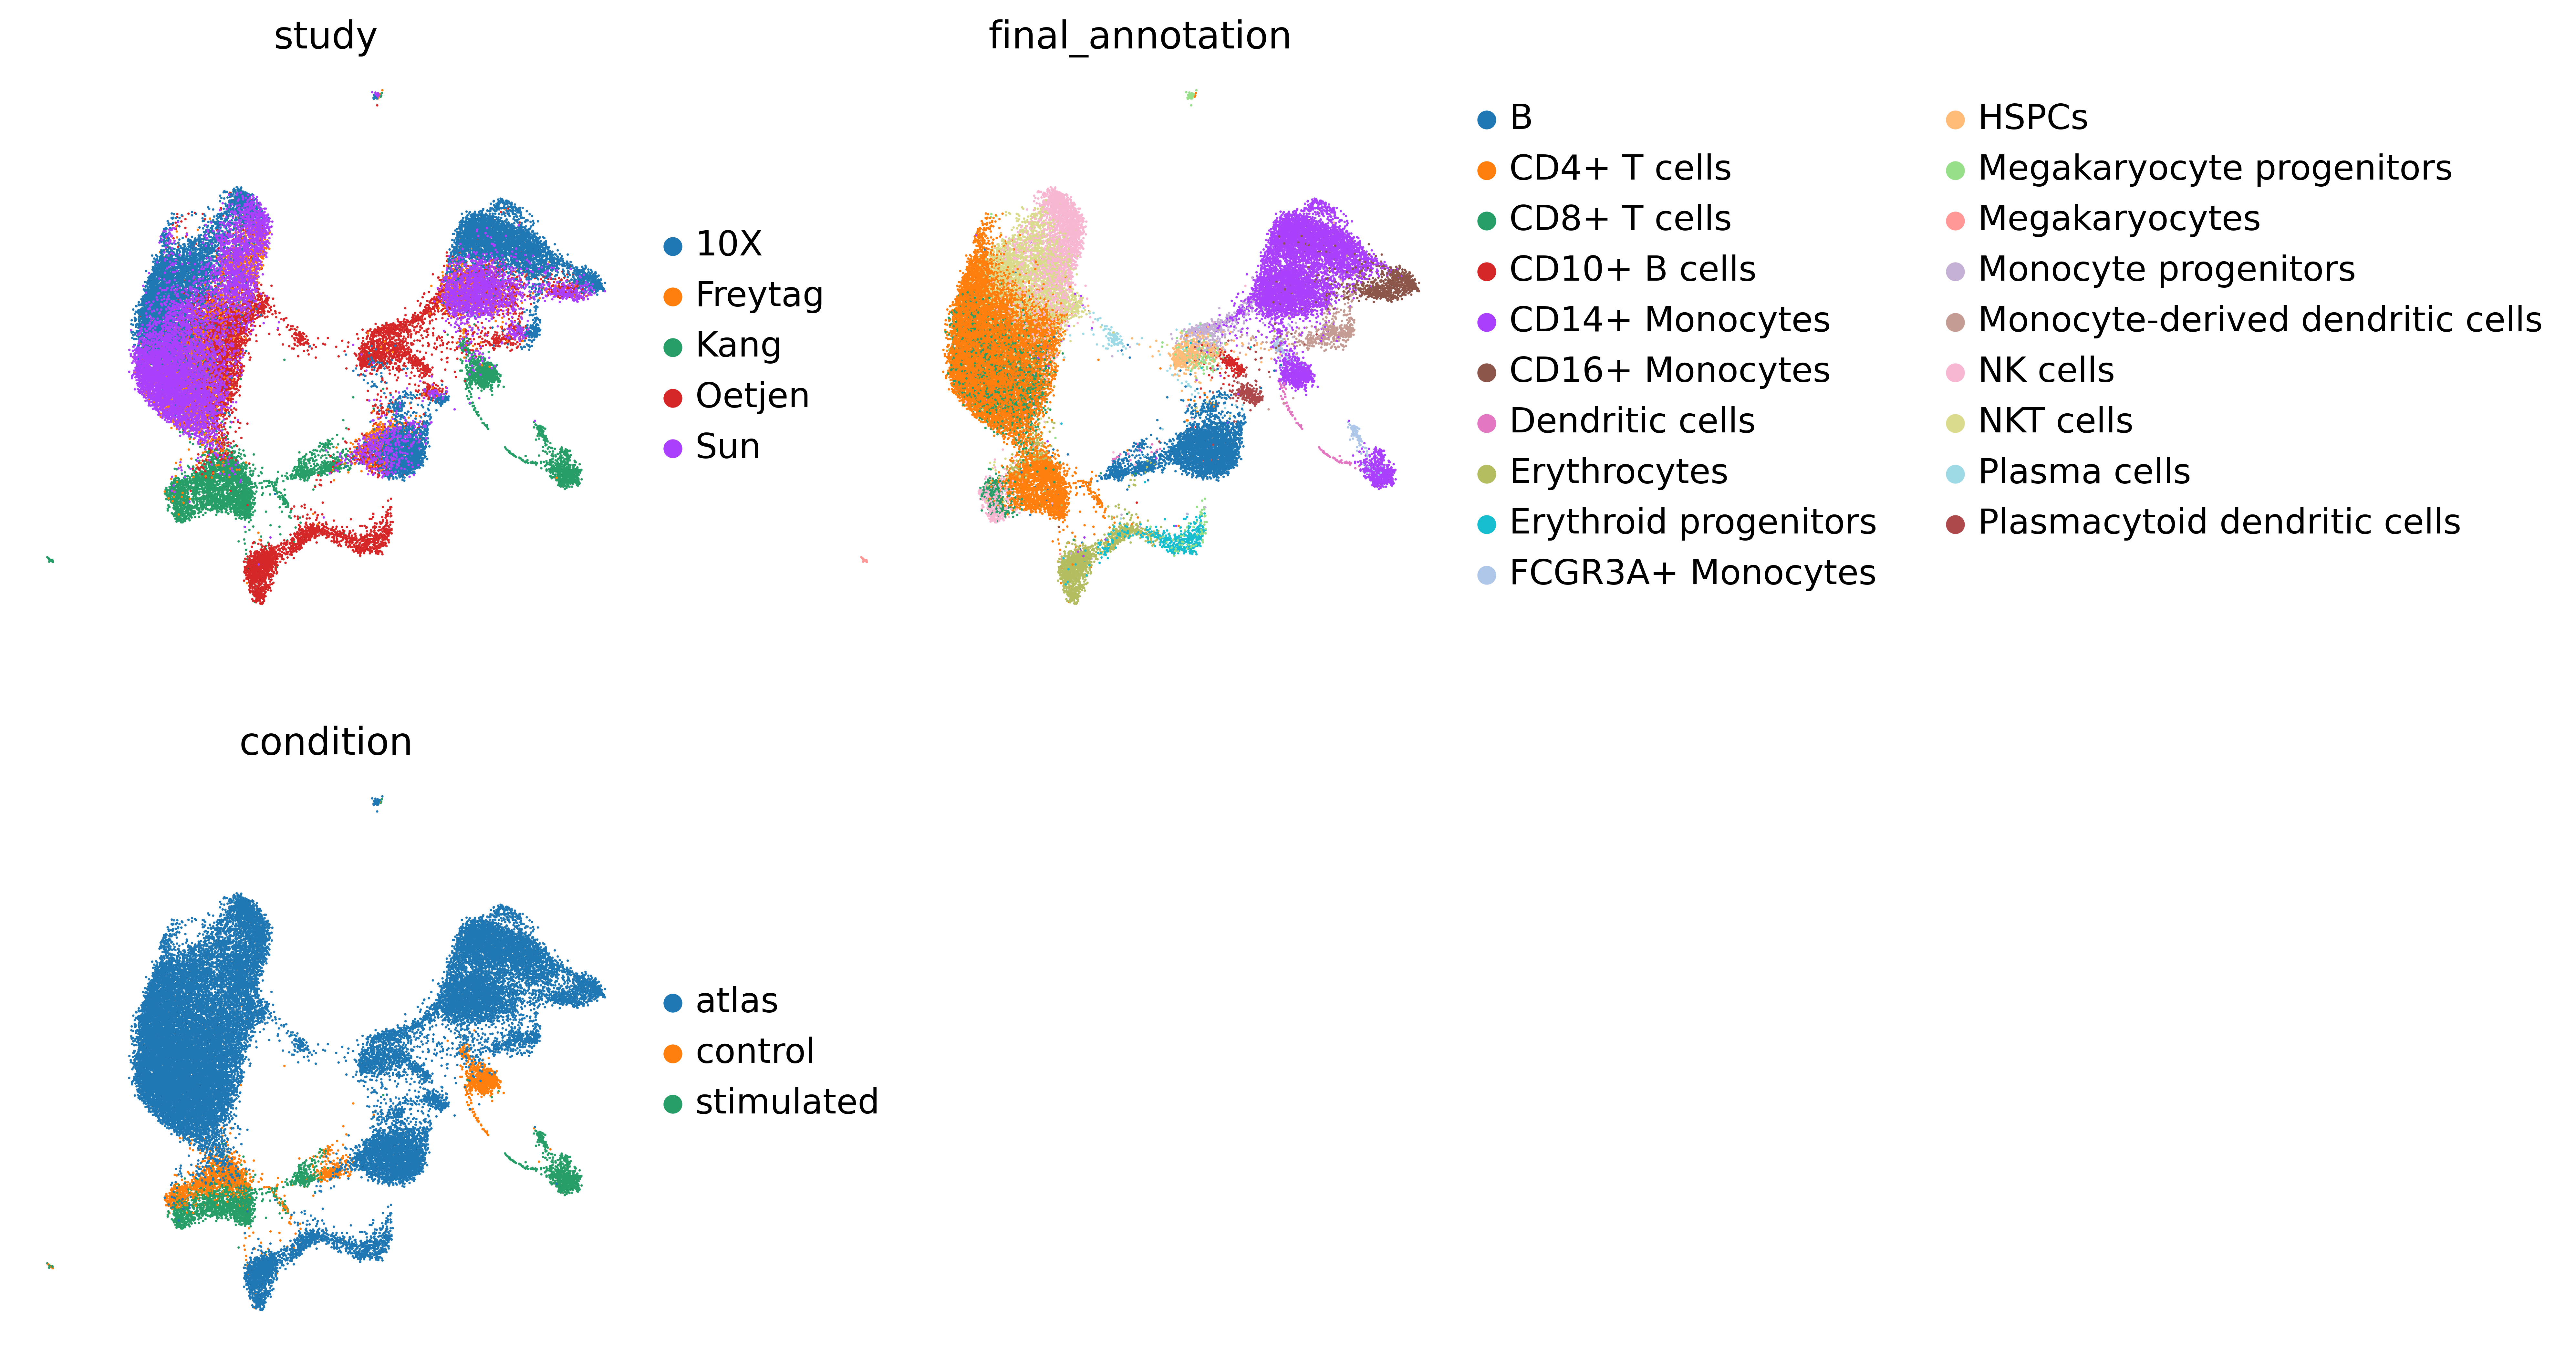

In [21]:
atlas_encoded = encoder.predict(x_new, batch_size=batch_size)[0]
atlas_encoded = pd.DataFrame(atlas_encoded, index=x_new.index)

adata = sc.AnnData(X=atlas_encoded)
adata.obs = y_new.loc[x_new.index]

# sc.pp.log1p(adata)
sc.pp.neighbors(adata, use_rep="X", random_state=42)
sc.tl.leiden(adata, random_state=42)
sc.tl.umap(adata, random_state=42)
sc.pl.umap(
    adata, color=["study", "final_annotation", "condition"], frameon=False, ncols=2
)

/home/cloucera/github/robustness_informed/.venvs/ivae/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1208: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(values):
/home/cloucera/github/robustness_informed/.venvs/ivae/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/cloucera/github/robustness_informed/.venvs/ivae/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/cloucera/github/robustness_informe

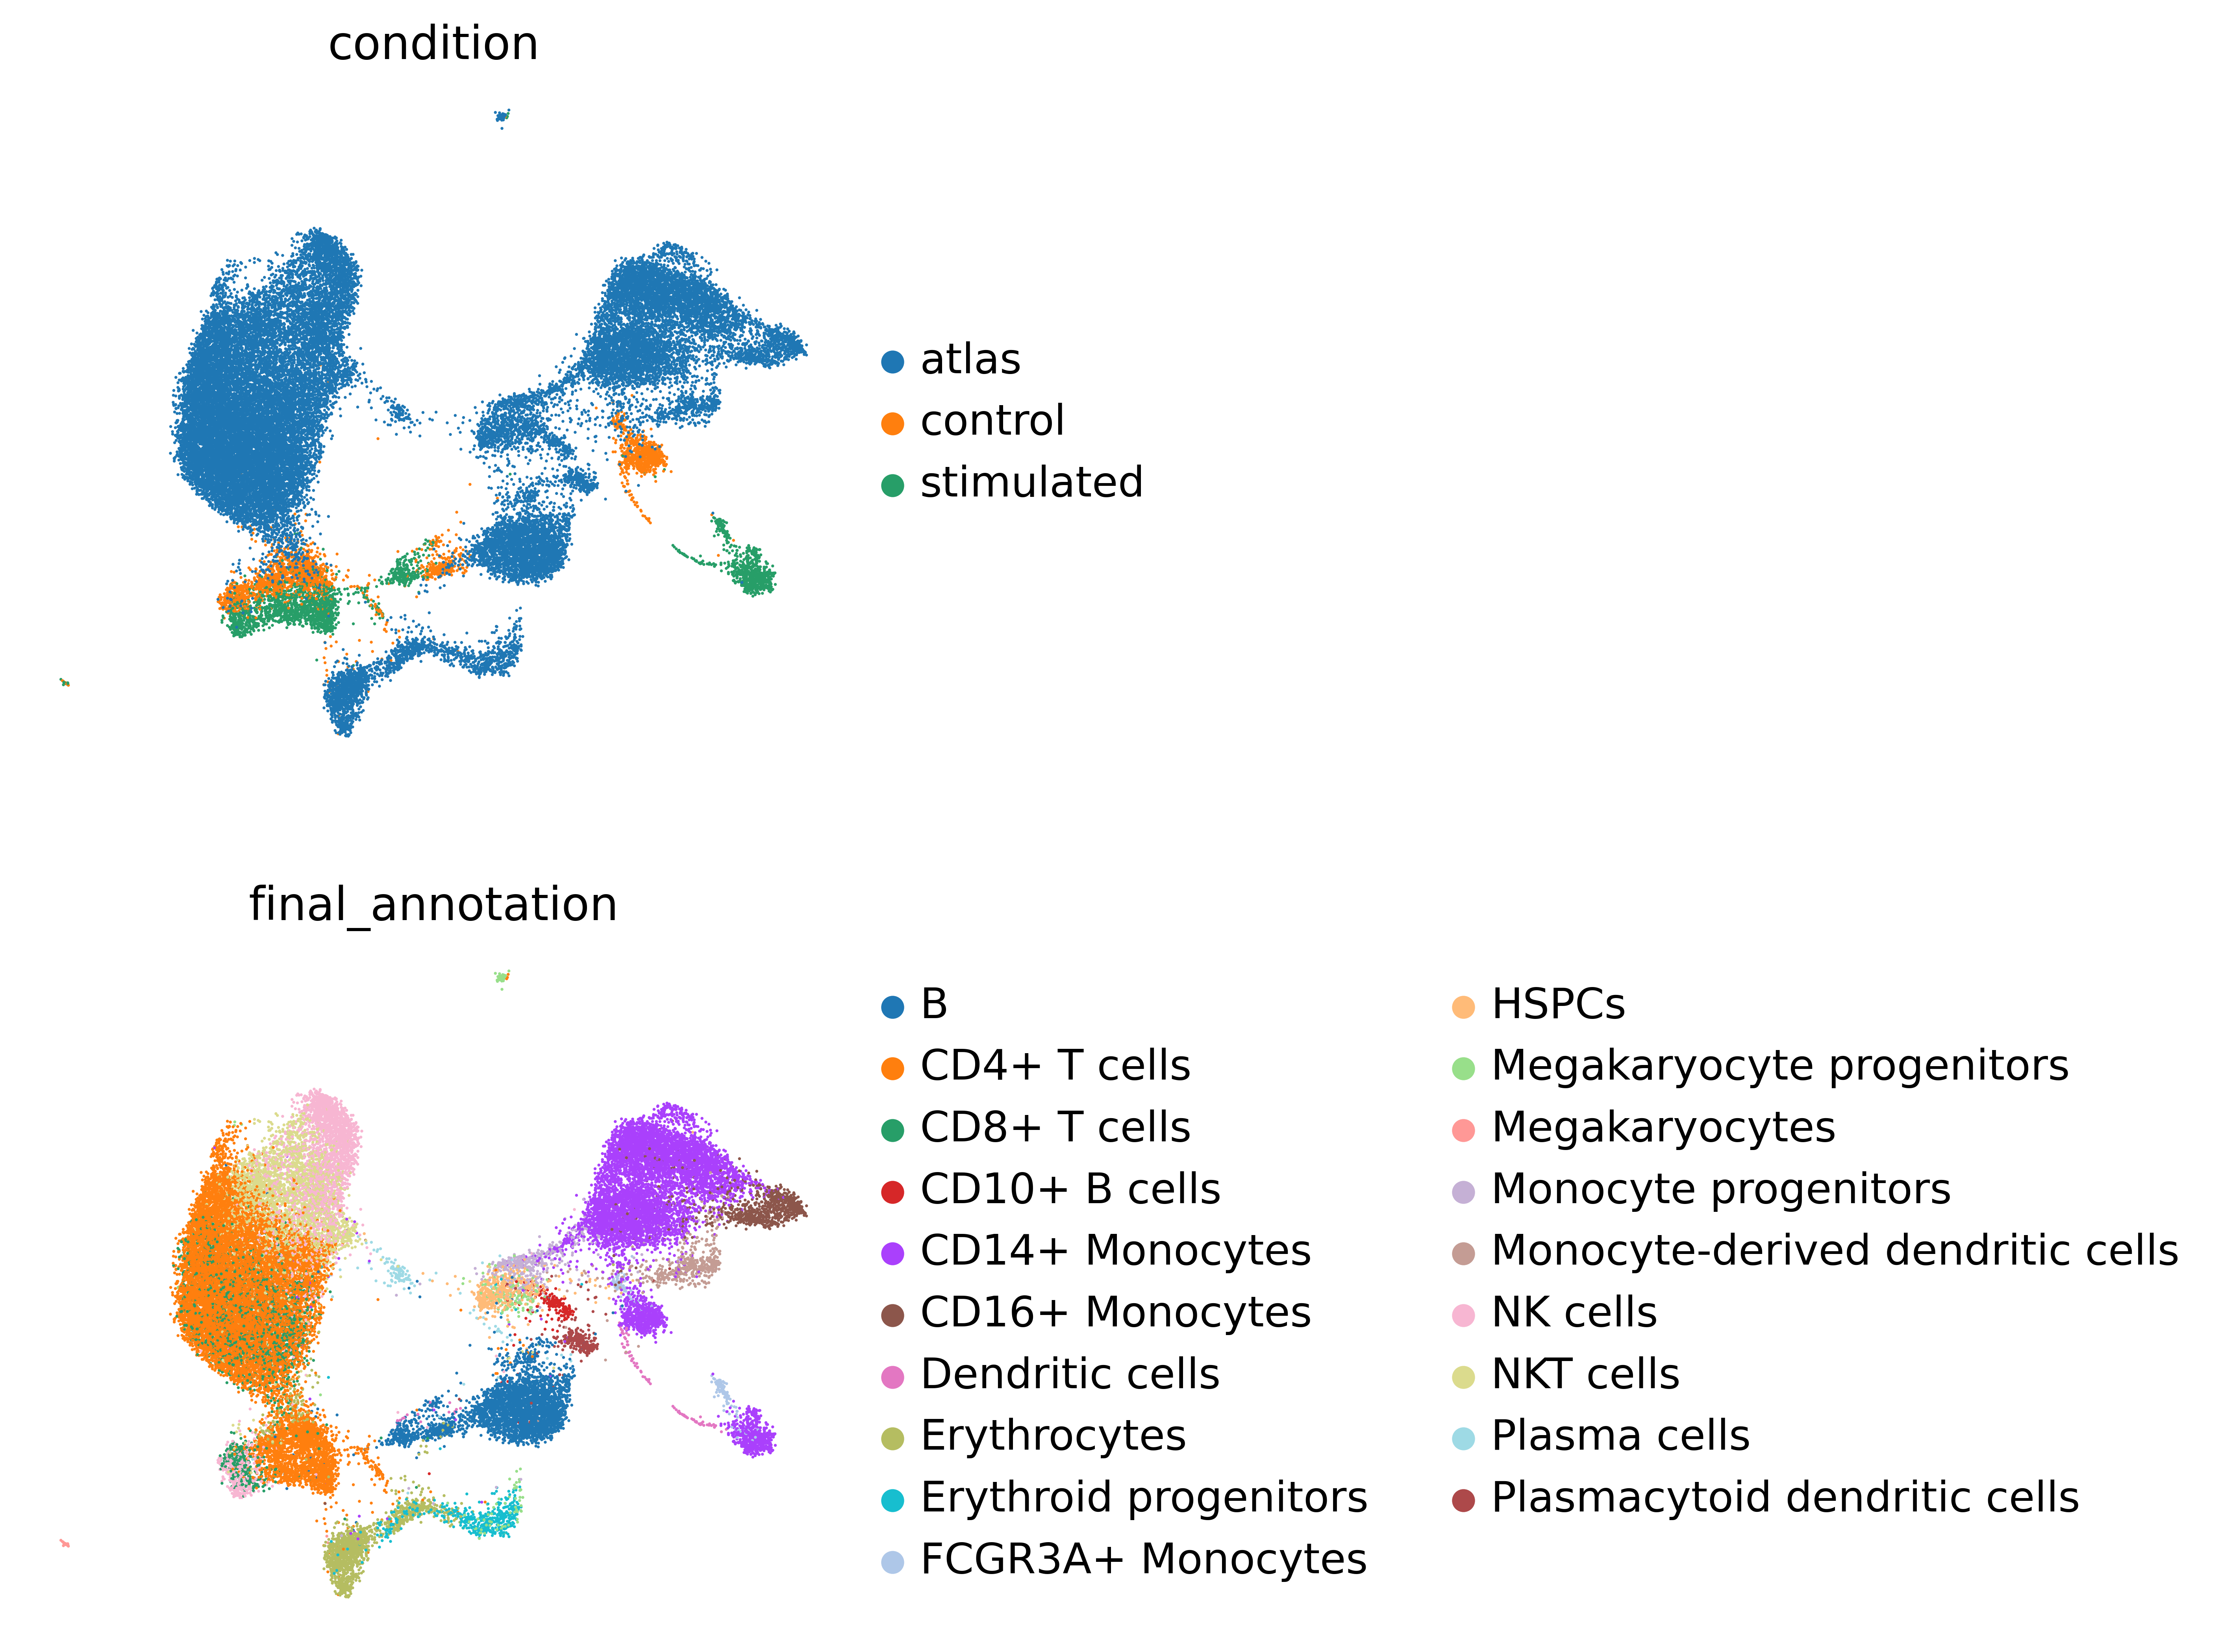

In [24]:
sc.pl.umap(adata, color=["condition", "final_annotation"], frameon=False, ncols=1)